X Shape: (150, 4)
y Shape: (150,)
k-NN accuracy: 0.7111111111111111
Confusion matrix:
 [[15  0  0]
 [ 0  6  9]
 [ 0  4 11]]


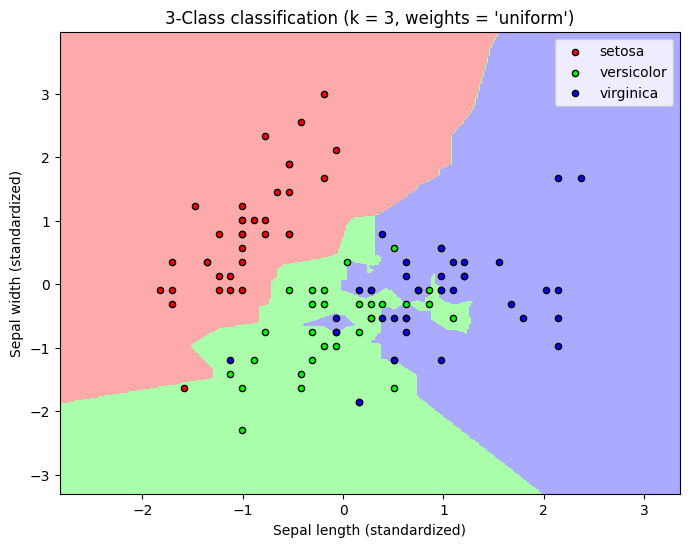

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

def exercise_knn_iris():
    """
    Exercise 1:
    - Load Iris
    - Standardize features
    - Train k-NN with k=3
    - Report accuracy and confusion matrix
    """
    # 1. Load Data
    # For visualization, we will only use the first two features (Sepal Length, Sepal Width)
    X, y = load_iris(return_X_y=True)
    print(f"X Shape: {X.shape}")
    print(f"y Shape: {y.shape}")
    X = X[:, :2]  # We only take the first two features.

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

    # 2. Scale Features (Crucial for k-NN because it uses distance!)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # 3. Train Model
    # k=3 means we look at 3 neighbors
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train_s, y_train)

    # 4. Predict and Evaluate
    y_pred = knn.predict(X_test_s)

    print("k-NN accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

    # 5. Visualize Decision Boundary
    # Create color maps
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ['#FF0000', '#00FF00', '#0000FF']

    # Meshgrid for plotting
    x_min, x_max = X_train_s[:, 0].min() - 1, X_train_s[:, 0].max() + 1
    y_min, y_max = X_train_s[:, 1].min() - 1, X_train_s[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=cmap_light)

    # Plot also the training points
    for i, color in enumerate(cmap_bold):
        idx = np.where(y_train == i)
        plt.scatter(X_train_s[idx, 0], X_train_s[idx, 1], c=color,
                    label=load_iris().target_names[i], edgecolor='black', s=20)

    plt.title("3-Class classification (k = 3, weights = 'uniform')")
    plt.xlabel('Sepal length (standardized)')
    plt.ylabel('Sepal width (standardized)')
    plt.legend()
    plt.show()

exercise_knn_iris()